In [1]:
import sys
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean as cmo
plt.style.use('src/ryan_mplstyle.mplstyle')

from scipy.ndimage import convolve1d
from scipy.signal import convolve2d
from scipy.signal.windows import hamming

SRC_DIR = (Path.cwd() /'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from draw_gaussian_field_from_spectrum import draw_gaussian_field_from_spectrum
from matern_spectral_density_2d import matern_spectral_density_2d

In [2]:
# Define a SWOT swath of 50x500 km
# With 250 m posting
Lx, Ly = 50, 500  # km
dx, dy = 0.25, 0.25  # km
# Grid for 2km posting (for downsampling after filtering)
dy_2km = 2  # km

Nx, Ny = int(Lx / dx), int(Ly / dy)
Lx, Ly = dx * Nx, dy * Ny

k = np.fft.fftfreq(Nx, d=dx)
l = np.fft.fftfreq(Ny, d=dy)
k_mat, l_mat = np.meshgrid(k, l)
Ka_mat = np.sqrt(k_mat**2 + l_mat**2)
x = np.arange(-Lx / 2, Lx / 2, Lx / Nx)
y = np.arange(-Ly / 2, Ly / 2, Ly / Ny)
x_mat, y_mat = np.meshgrid(x, y)

l_2km = np.fft.fftfreq(int(Ly/dy_2km), d=dy_2km)
downsample_stride = int(round(dy_2km / dy))

repeat_num = 200 # total ensumble number
repeat_batch_size = 50 # processed in smaller batch size to fit in memory
batch_sizes = [repeat_batch_size] * (repeat_num // repeat_batch_size)
if repeat_num % repeat_batch_size:
    batch_sizes.append(repeat_num % repeat_batch_size)

In [3]:
# Create a "Balanced" spectrum using the 2D Matern PSD;
# with nu=1.5 the small-scale slope is -5, which is -4 in isotropic and along-track spectra
Bal_spec = matern_spectral_density_2d(Ka_mat, 1.5, l=50) * 8
Bal_spec[0, 0] = 0

# Noise
SWH_values = np.array([2, 3, 4, 5, 6])
noise_mag_values = np.array([0.96, 1.32, 1.77, 2.33, 2.95])**2
# Normalize so SWH=2 m is the reference noise level.
noise_mag_values = noise_mag_values / noise_mag_values[SWH_values == 2][0]
noise_mag_by_swh = dict(zip(SWH_values, noise_mag_values))

noisefloor_2km = 2*(15/0.5)/(2.3**2)
noise_spec_val = noisefloor_2km/(50/0.25)

# Base white-noise magnitude; the loop scales this by noise_mag
base_noise_spec = np.ones(Bal_spec.shape) * noise_spec_val

In [4]:
# Prebuild total spectra for each sea-state case.
specs_by_noise = {}
for SWH_here in SWH_values:
    noise_mag = noise_mag_by_swh[SWH_here]
    Noise_spec = base_noise_spec * noise_mag
    Tot_spec = Bal_spec + Noise_spec
    Tot_spec[0, 0] = 0

    specs_by_noise[SWH_here] = {
        'Noise_spec': Noise_spec,
        'Tot_spec': Tot_spec,
    }

# Running sums for ensumble averages.
unfiltered_spectra_sum = {
    SWH_here: np.zeros_like(l, dtype=float) for SWH_here in SWH_values
}
filtered_spectra_sum = {
    SWH_here: np.zeros_like(l, dtype=float) for SWH_here in SWH_values
}
filtered_spectra2km_sum = {
    SWH_here: np.zeros_like(l_2km, dtype=float) for SWH_here in SWH_values
}
# Only keep the 1D-filter comparison for the 6 m sea-state.
filtered_spectra1d_2km_sum = np.zeros_like(l_2km, dtype=float)

In [5]:
# Create the 2D 17 point Hamming window filter used in SWOT processing to create the 2km data
window_size = 17

# 1D along-track Hamming weights used for the comparison case.
hamm_1d = hamming(window_size)
hamm_1d = hamm_1d / hamm_1d.sum()

# Create 2D filter using outer product and normalize it for convolution
hamm_filt2d = np.outer(hamm_1d, hamm_1d)
hamm_filt2d = hamm_filt2d / hamm_filt2d.sum()

In [6]:
start_idx = 0

for current_batch_size in batch_sizes:
    for SWH_here, payload in specs_by_noise.items():
        # Draw a batch of random SSH realizations from the target PSD.
        SSH_hat, SSH = draw_gaussian_field_from_spectrum(
            payload['Tot_spec'], current_batch_size
        )
        # Compute along-track PSD (axis=1) for the unfiltered SSH
        unfiltered_spectra_sum[SWH_here] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH, norm='forward', axis=1))**2, axis=(0, 2)
        )

        # Apply SWOT-like 2D Hamming smoothing before downsampling.
        SSH_filt = np.stack(
            [convolve2d(field, hamm_filt2d, mode='same', boundary='wrap') for field in SSH],
            axis=0,
        )

        # Downsample to 2km posting
        SSH_filt_2km = SSH_filt[:, 0::downsample_stride, :]
        # Compute along-track PSD (axis=1) for the 2D filtered and aliased SSH
        filtered_spectra2km_sum[SWH_here] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH_filt_2km, norm='forward', axis=1))**2, axis=(0, 2)
        )

        # Do not downsample so as to not alias
        filtered_spectra_sum[SWH_here] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH_filt, norm='forward', axis=1))**2, axis=(0, 2)
        )

        if SWH_here == 6:
            # Apply a 1D along-track Hamming filter only for the 6 m comparison case.
            SSH_1Dfilt = np.stack(
                [convolve1d(field, weights=hamm_1d, axis=0, mode='wrap') for field in SSH],
                axis=0,
            )
            filtered_spectra1d_2km_sum += current_batch_size * np.mean(
                np.abs(np.fft.fft(SSH_1Dfilt[:, 0::downsample_stride, :], norm='forward', axis=1))**2,
                axis=(0, 2),
            )

    start_idx += current_batch_size
    print(start_idx)

50
100
150
200


In [7]:
# Averaged along-track spectra for unfiltered SSH
unfiltered_spectra_by_noise = {
    SWH_here: {'total': unfiltered_spectra_sum[SWH_here] / repeat_num}
    for SWH_here in SWH_values
}

# Averaged along-track spectra for 2D filtered SSH
filtered_spectra_by_noise = {
    SWH_here: {'total': filtered_spectra_sum[SWH_here] / repeat_num}
    for SWH_here in SWH_values
}

# Averaged along-track spectra for 2D filtered and downsampled SSH
filtered_spectra2km_by_noise = {
    SWH_here: {'total': filtered_spectra2km_sum[SWH_here] / repeat_num}
    for SWH_here in SWH_values
}

# Averaged along-track spectrum for the 1D filtered 6 m SSH case
SSH_1Dfilt_alongtrack_spec = filtered_spectra1d_2km_sum / repeat_num

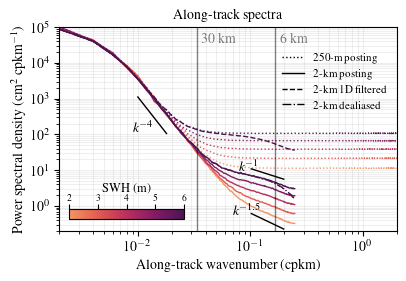

In [8]:
fig, ax = plt.subplots(figsize=(10 / 2.4, 7 / 2.4))

# Keep only positive frequencies for one-sided PSD visualization.
positive_wavenumber = l > 0
pw_cut = positive_wavenumber & (l < 1 / 4)
positive_wavenumber_2km = l_2km > 0

# Color-code lines by SWH.
swh_plot_order = np.sort(np.asarray(SWH_values))
swh_norm_lines = colors.Normalize(vmin=swh_plot_order.min()-1.5, vmax=swh_plot_order.max() + 0.5)
swh_cmap = cmo.cm.matter
swh_colors = swh_cmap(swh_norm_lines(swh_plot_order))

for swh_value, line_color in zip(swh_plot_order, swh_colors):
    unfiltered_spec = unfiltered_spectra_by_noise[swh_value]['total']
    ax.loglog(l[positive_wavenumber], unfiltered_spec[positive_wavenumber], ':', color=line_color, alpha=0.95)

    filtered2km_spec = filtered_spectra2km_by_noise[swh_value]['total']
    ax.loglog(
        l_2km[positive_wavenumber_2km],
        filtered2km_spec[positive_wavenumber_2km],
        '-',
        color=line_color,
    )

# No aliasing case
filtered_spec = filtered_spectra_by_noise[6]['total']
ax.loglog(
    l[pw_cut],
    filtered_spec[pw_cut],
    '-.',
    color=swh_colors[-1,:],
)

# Overlay the 1D-filtered + downsampled spectrum only for the 6 m case.
ax.loglog(
    l_2km[positive_wavenumber_2km],
    SSH_1Dfilt_alongtrack_spec[positive_wavenumber_2km],
    '--',
    color=line_color,
)

# Reference slopes for visual comparison
l_ref = l[(l > 8e-3) & (l < 2e-2)]
ax.loglog(l_ref, l_ref**(-4) / 9e4, '-', color='k')
ax.text(0.9e-2, 120, r'$k^{-4}$', color='k')
l_pos = l[(l > 10e-2) & (l < 0.2)]
ax.loglog(l_pos, l_pos**(-1) / 0.9, '-', color='k')
ax.text(8e-2, 10, r'$k^{-1}$', color='k')
ax.loglog(l_pos, l_pos**(-1.5) / 50, '-', color='k')
ax.text(7e-2, 0.6, r'$k^{-1.5}$', color='k')

# Annotate the 6 km and 30 km wavenumbers
ymax = 1e5
ax.axvline(1 / 30, color='black', alpha=0.5)
ax.axvline(1 / 6, color='black', alpha=0.5)
ax.text(1 / 30 * 1.1, ymax * 0.7, '30 km', verticalalignment='top', alpha=0.5)
ax.text(1 / 6 * 1.1, ymax * 0.7, '6 km', verticalalignment='top', alpha=0.5)

ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel(r"Power spectral density (cm$^2$ cpkm$^{-1}$)")
ax.set_title('Along-track spectra')
ax.grid(True, which='both', alpha=0.2)

# Colorbar for SWH values
swh_sm = plt.cm.ScalarMappable(cmap=swh_cmap, norm=swh_norm_lines)
swh_sm.set_array([])
swh_cax = ax.inset_axes([0.03, 0.06, 0.34, 0.05])
swh_cbar = fig.colorbar(swh_sm, cax=swh_cax, orientation='horizontal')
swh_cbar.set_label('SWH (m)', fontsize=9, labelpad=2)
swh_cbar.set_ticks(swh_plot_order)
swh_cbar.ax.tick_params(labelsize=7, pad=1)
swh_cbar.ax.set_xlim(2, 6)
swh_cbar.ax.xaxis.set_label_position('top')
swh_cbar.ax.xaxis.set_ticks_position('top')

# Custom legend
style_handles = [
    plt.Line2D([0], [0], color='k', linestyle=':', label='250-m posting'),
    plt.Line2D([0], [0], color='k', linestyle='-', label='2-km posting'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='2-km 1D filtered'),
    plt.Line2D([0], [0], color='k', linestyle='-.', label='2-km dealiased'),
]
ax.legend(handles=style_handles, loc='upper right', bbox_to_anchor=(1.0, 0.92), frameon=False)

ax.set_xlim([2e-3, 2])
ax.set_ylim([2e-1, ymax])

plt.tight_layout()
plt.savefig('figs/Hamm_whitered.pdf', bbox_inches='tight')
plt.show()